# Lab 7: Decision Tree Classification

## Aim
To implement and evaluate a Decision Tree classifier using the Iris dataset, exploring the effect of different hyperparameters.

## Objectives
- To explore and preprocess the Iris dataset.
- To train a Decision Tree classifier and visualize it.
- To compare Gini and Entropy criteria.
- To study the impact of `max_depth`, `min_samples_split`, and `min_samples_leaf` on the model.
- To perform hyperparameter tuning using GridSearchCV.


### TASK 1: DATASET EXPLORATION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV

data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
print('Feature names:', data.feature_names)
print('Target names:', data.target_names)
print('Number of samples:', len(df))
print('Dataset shape:', df.shape)
print('First five records:')
display(df.head())
print('\nDataset Information:')
df.info()
print('\nStatistics:')
display(df.describe())
print('\nMissing values:\n', df.isnull().sum())
print('\nClass distribution:\n', df['target'].value_counts())

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Number of samples: 150
Dataset shape: (150, 5)
First five records:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB

Statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000



Missing values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

Class distribution:
 target
0    50
1    50
2    50
Name: count, dtype: int64


### TASK 2: DATA PREPARATION

In [2]:
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print('Training size:', len(X_train))
print('Testing size:', len(X_test))

Training size: 105
Testing size: 45


### TASK 3: BUILDING A DECISION TREE CLASSIFIER

In [3]:
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)
y_pred = dt_clf.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
 [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



### TASK 4: VISUALIZING THE DECISION TREE

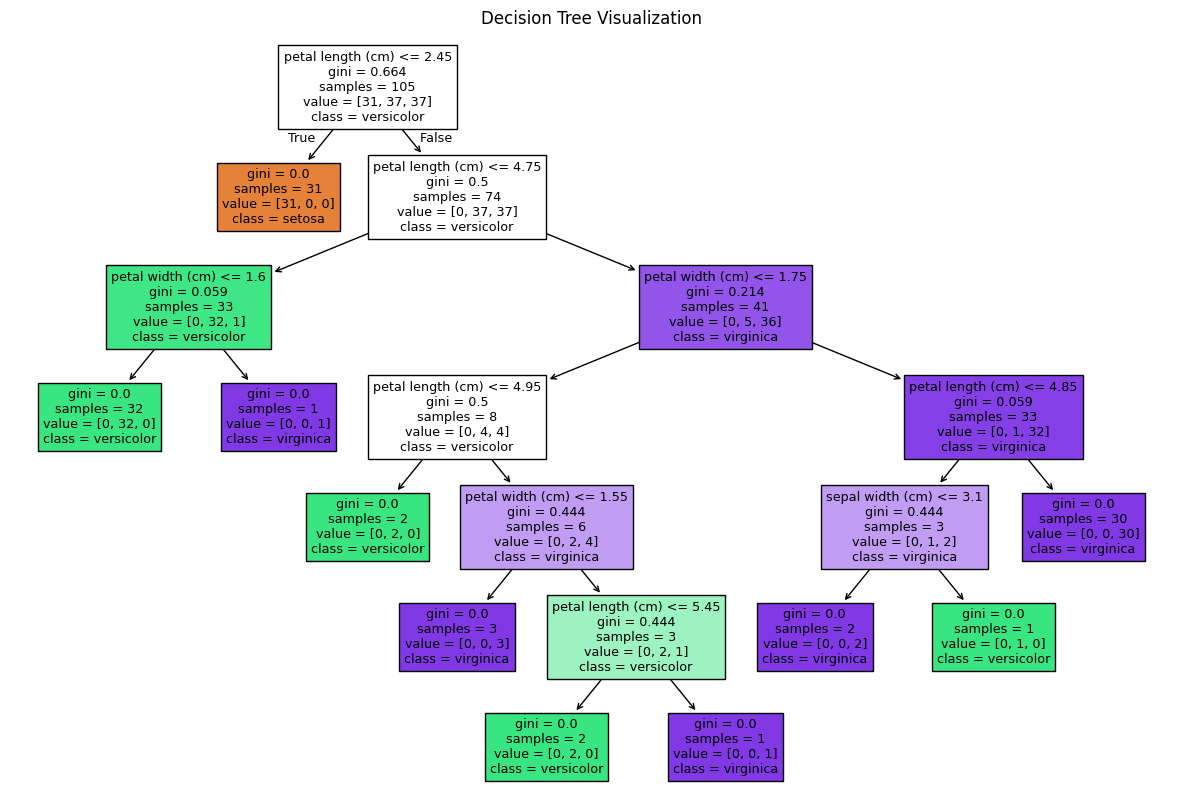

In [4]:
plt.figure(figsize=(15, 10))
plot_tree(dt_clf, feature_names=data.feature_names, class_names=data.target_names, filled=True)
plt.title('Decision Tree Visualization')
plt.show()

### TASK 5: COMPARING GINI AND ENTROPY

In [5]:
dt_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)

dt_gini.fit(X_train, y_train)
dt_entropy.fit(X_train, y_train)

acc_gini = accuracy_score(y_test, dt_gini.predict(X_test))
acc_entropy = accuracy_score(y_test, dt_entropy.predict(X_test))

comp_df = pd.DataFrame({
    'Criterion': ['Gini', 'Entropy'],
    'Accuracy': [acc_gini, acc_entropy],
    'Tree Depth': [dt_gini.get_depth(), dt_entropy.get_depth()],
    'Leaf Nodes': [dt_gini.get_n_leaves(), dt_entropy.get_n_leaves()],
    'Root Feature': [data.feature_names[dt_gini.tree_.feature[0]], data.feature_names[dt_entropy.tree_.feature[0]]]
})
display(comp_df)

,Criterion,Accuracy,Tree Depth,Leaf Nodes,Root Feature
0,Gini,1.000000,6,10,petal length (cm)
1,Entropy,0.977778,7,10,petal length (cm)


### TASK 6: EFFECT OF MAXIMUM TREE DEPTH

,max_depth,Train Accuracy,Test Accuracy,Tree Depth,Leaf Nodes
0,1,0.647619,0.711111,1,2
1,2,0.942857,0.977778,2,3
2,3,0.952381,1.000000,3,5
3,4,0.971429,1.000000,4,7
4,5,0.990476,1.000000,5,9
5,None,1.000000,1.000000,6,10


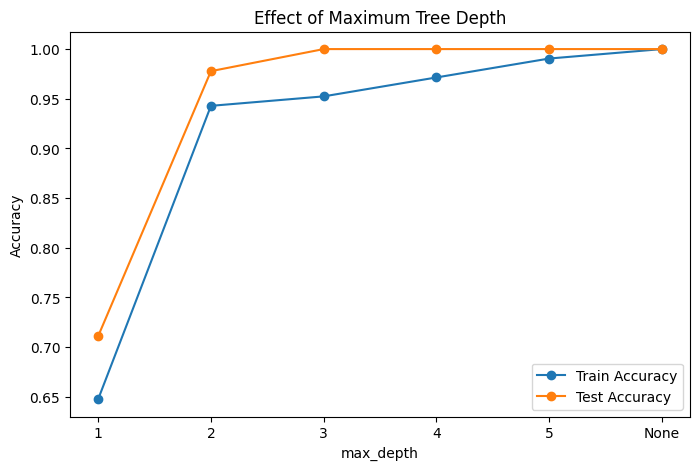

In [6]:
max_depths = [1, 2, 3, 4, 5, None]
depth_results = []

for depth in max_depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, dt.predict(X_train))
    test_acc = accuracy_score(y_test, dt.predict(X_test))
    depth_results.append({
        'max_depth': depth if depth else 'None',
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Tree Depth': dt.get_depth(),
        'Leaf Nodes': dt.get_n_leaves()
    })

depth_df = pd.DataFrame(depth_results)
display(depth_df)

plt.figure(figsize=(8, 5))
plt.plot([str(d) for d in max_depths], depth_df['Train Accuracy'], label='Train Accuracy', marker='o')
plt.plot([str(d) for d in max_depths], depth_df['Test Accuracy'], label='Test Accuracy', marker='o')
plt.title('Effect of Maximum Tree Depth')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### TASK 7: EFFECT OF min_samples_split

,min_samples_split,Train Accuracy,Test Accuracy,Tree Depth,Leaf Nodes
0,2,1.000000,1.0,6,10
1,5,0.980952,1.0,5,8
2,10,0.952381,1.0,4,6
3,20,0.952381,1.0,4,6


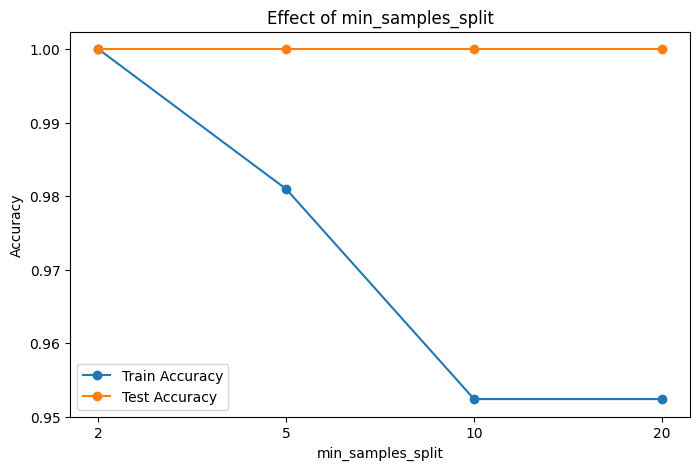

In [7]:
min_samples_splits = [2, 5, 10, 20]
split_results = []

for split in min_samples_splits:
    dt = DecisionTreeClassifier(min_samples_split=split, random_state=42)
    dt.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, dt.predict(X_train))
    test_acc = accuracy_score(y_test, dt.predict(X_test))
    split_results.append({
        'min_samples_split': split,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Tree Depth': dt.get_depth(),
        'Leaf Nodes': dt.get_n_leaves()
    })

split_df = pd.DataFrame(split_results)
display(split_df)

plt.figure(figsize=(8, 5))
plt.plot([str(s) for s in min_samples_splits], split_df['Train Accuracy'], label='Train Accuracy', marker='o')
plt.plot([str(s) for s in min_samples_splits], split_df['Test Accuracy'], label='Test Accuracy', marker='o')
plt.title('Effect of min_samples_split')
plt.xlabel('min_samples_split')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### TASK 8: EFFECT OF min_samples_leaf

,min_samples_leaf,Train Accuracy,Test Accuracy,Tree Depth,Leaf Nodes
0,1,1.000000,1.000000,6,10
1,2,0.971429,1.000000,5,8
2,5,0.942857,1.000000,4,6
3,10,0.942857,0.977778,3,5


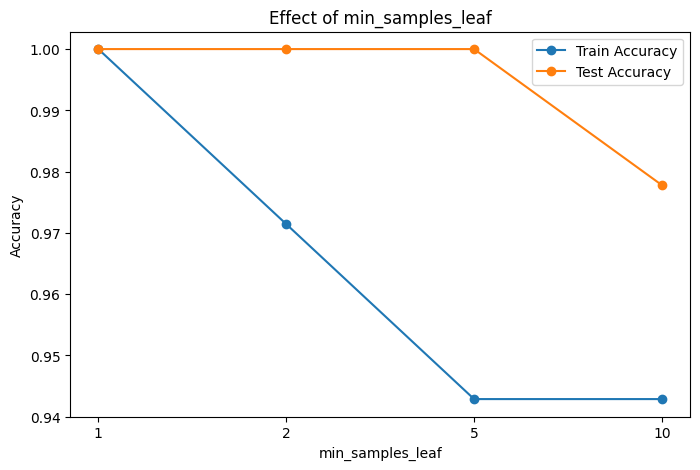

In [8]:
min_samples_leafs = [1, 2, 5, 10]
leaf_results = []

for leaf in min_samples_leafs:
    dt = DecisionTreeClassifier(min_samples_leaf=leaf, random_state=42)
    dt.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, dt.predict(X_train))
    test_acc = accuracy_score(y_test, dt.predict(X_test))
    leaf_results.append({
        'min_samples_leaf': leaf,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Tree Depth': dt.get_depth(),
        'Leaf Nodes': dt.get_n_leaves()
    })

leaf_df = pd.DataFrame(leaf_results)
display(leaf_df)

plt.figure(figsize=(8, 5))
plt.plot([str(l) for l in min_samples_leafs], leaf_df['Train Accuracy'], label='Train Accuracy', marker='o')
plt.plot([str(l) for l in min_samples_leafs], leaf_df['Test Accuracy'], label='Test Accuracy', marker='o')
plt.title('Effect of min_samples_leaf')
plt.xlabel('min_samples_leaf')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

### TASK 9: HYPERPARAMETER TUNING

In [9]:
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

grid_search = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42), param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

print('Best Parameters:', grid_search.best_params_)
print('Best CV Score:', grid_search.best_score_)

opt_model = grid_search.best_estimator_
opt_test_acc = accuracy_score(y_test, opt_model.predict(X_test))
print('Optimized Test Accuracy:', opt_test_acc)

comparison = pd.DataFrame({
    'Model': ['Default', 'Optimized'],
    'Test Accuracy': [accuracy_score(y_test, dt_clf.predict(X_test)), opt_test_acc]
})
display(comparison)

Best Parameters: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best CV Score: 0.9428571428571428
Optimized Test Accuracy: 1.0


,Model,Test Accuracy
0,Default,1.0
1,Optimized,1.0


### TASK 10: ANALYSIS
**Observations:**
- `criterion`: Both Gini and Entropy produce similar results in most cases.
- `max_depth`: Limiting depth prevents overfitting; a completely unconstrained tree might overfit.
- `min_samples_split` & `min_samples_leaf`: Increasing these constraints reduces tree complexity.
- Best hyperparameters were found using GridSearchCV, which yielded an optimized and simpler model without sacrificing accuracy.

**Conclusion & Learning Outcomes**
The Decision Tree classifier is highly interpretable but prone to overfitting without regularization (pruning). Grid search effectively determines the best combination of hyperparameters.